In [1]:
import numpy as np 
import pickle 
import h5py
from scipy import stats
from tqdm.auto import tqdm



In [2]:
ls binaural_model_attn_stage_reps/

word_task_half_co_loc_v07/
word_task_half_co_loc_v07_model_activations_0dB.h5
word_task_half_co_loc_v07_model_activations_0dB_compare_with_attn.h5
word_task_half_co_loc_v07_model_activations_0dB_corrs.pkl
word_task_half_co_loc_v07_model_activations_0dB_no_attention.h5
word_task_half_co_loc_v07_model_activations_0dB_no_attention_corrs.pkl
word_task_standard_v07_model_activations_0dB.h5
word_task_standard_v07_model_activations_0dB_corrs.pkl


In [3]:
# Get model activation files 
from pathlib import Path 

out_dir = Path('binaural_model_attn_stage_reps/')
# paths = list(out_dir.glob('*model_activations_0dB.h5'))

path  = Path("binaural_model_attn_stage_reps/word_task_half_co_loc_v07_model_activations_0dB_compare_with_attn.h5")

In [4]:
out_dir

PosixPath('binaural_model_attn_stage_reps')

In [5]:
# acts =  h5py.File(path, 'r')
# print(acts.keys())
# layer_names = [key.split("_mixture")[0] for key in acts.keys() if "mixture" in key]
# print(layer_names)


# ### Test method that doesn't compute full covariance matrix
# n_to_use = 100
# # get mixture acts 
# layer = layer_names[1]
# mixture_acts = acts[f"{layer}_mixture"][:n_to_use, :]
# target_acts = acts[f"{layer}_fg"][:n_to_use, :]
# bg_acts = acts[f"{layer}_bg"][:n_to_use, :]

# # get mixture acts
# # fg_r = np.corrcoef(mixture_acts, target_acts)
# # matrix_corrs = np.diagonal(fg_r[:n_to_use, n_to_use:])
# # try with pearsonr
# pearson_corrs = [stats.pearsonr(target_acts, mixture_acts)[0] for mixture_acts, target_acts in zip(mixture_acts, target_acts)]
# print(f"{layer} target corr {np.mean(pearson_corrs):.3f} {stats.sem(pearson_corrs):.3f}")

# # try with pearsonr
# pearson_corrs = [stats.pearsonr(bg_acts, mixture_acts)[0] for mixture_acts, bg_acts in zip(mixture_acts, bg_acts)]
# print(f"{layer} background corr {np.mean(pearson_corrs):.3f} {stats.sem(pearson_corrs):.3f}")

# acts.close()

## Run full thing and save - will move to script in future 

In [6]:
with h5py.File(path, 'r') as f:
    layer_names = [key.split("_mixture")[0] for key in f.keys() if "mixture" in key]
    print(layer_names)
    corr_results = {}
    
    out_name = f"{path.stem}_corrs.pkl"
    # Save results as dict
    out_name = out_dir / out_name
    print(out_name)
    N_acts = f["cochleagram_mixture_w_attn"].shape[0]
    for layer in layer_names:
        w_attn = f[f"{layer}_mixture_w_attn"]
        no_attn = f[f"{layer}_mixture_no_attn"]

        corr_results[layer] = []

        for i in tqdm(range(N_acts), desc=f"Getting activations for {layer}", leave=False):
            corr_results[layer].append(stats.pearsonr(no_attn[i], w_attn[i])[0])
        
        # set type as float32
        corr_results[layer] = np.array(corr_results[layer], dtype=np.float32)
        
    out_dict = dict(corr_results=corr_results)

    with open(out_name ,'wb') as f:
        pickle.dump(out_dict, f)

['cochleagram', 'cochleagram', 'conv_block_0', 'conv_block_0', 'conv_block_1', 'conv_block_1', 'conv_block_2', 'conv_block_2', 'conv_block_3', 'conv_block_3', 'conv_block_4', 'conv_block_4', 'conv_block_5', 'conv_block_5', 'conv_block_6', 'conv_block_6', 'relufc', 'relufc']
binaural_model_attn_stage_reps/word_task_half_co_loc_v07_model_activations_0dB_compare_with_attn_corrs.pkl


Getting activations for cochleagram:   0%|          | 0/100 [00:00<?, ?it/s]

Getting activations for cochleagram:   0%|          | 0/100 [00:00<?, ?it/s]

Getting activations for conv_block_0:   0%|          | 0/100 [00:00<?, ?it/s]

Getting activations for conv_block_0:   0%|          | 0/100 [00:00<?, ?it/s]

...

Getting activations for conv_block_5:   0%|          | 0/100 [00:00<?, ?it/s]

Getting activations for conv_block_6:   0%|          | 0/100 [00:00<?, ?it/s]

Getting activations for conv_block_6:   0%|          | 0/100 [00:00<?, ?it/s]

Getting activations for relufc:   0%|          | 0/100 [00:00<?, ?it/s]

Getting activations for relufc:   0%|          | 0/100 [00:00<?, ?it/s]

In [7]:
## Make layer plot 

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import pickle 
import pandas as pd


In [8]:
# put results into dataframe
# put into df for easy plotting:

# load results

# out_name = out_dir / f"{paths[0].stem}_corrs.pkl"
# with open("binaural_model_attn_stage_reps/word_task_standard_v07_model_activations_0dB_corrs.pkl", 'rb') as f:
#     results = pickle.load(f)

# corr_results = results['corr_results']
# bg_corr_results = results['bg_corr_results']


dfs = []
for layer in corr_results.keys():
    df = pd.DataFrame.from_dict({'corrs':corr_results[layer],
                                 'layer': [layer] * len(corr_results[layer])})
            
    dfs.append(df)
corr_results = pd.concat(dfs)

corr_results['layer'] = corr_results['layer'].str.replace('_block_', '')

# results = pd.melt(corr_results, id_vars =['layer'], value_vars=['corrs'], var_name='Stream',
#                             value_name="Pearson's r")

In [11]:
corr_results.head()

,corrs,layer
0,1.000000,cochleagram
1,1.000000,cochleagram
2,1.000000,cochleagram
3,1.000000,cochleagram
4,1.000000,cochleagram
...,...,...
95,0.260662,relufc
96,0.335026,relufc
97,0.285776,relufc
98,0.318103,relufc


In [14]:
order = np.sort(corr_results.layer.unique())


In [15]:
results[results['Pearson\'s r'].isna()]

,layer,Stream,Pearson's r
80,cochleagram,target,NaN
926,cochleagram,distractor,NaN


In [15]:
# rename column corrs to Pearson's r
corr_results = corr_results.rename(columns={'corrs':"Pearson's r"})

Text(0.5, 0.98, 'Corr(mixture attend, mixture no attention)')

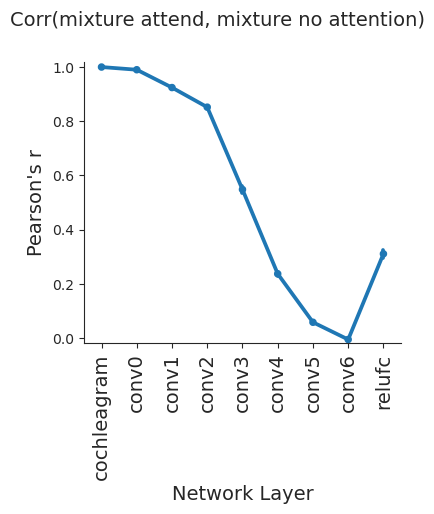

In [29]:
# to_plot = results[results['Pearson\'s r'].notna()]
sns.set_style('ticks')

p = sns.catplot(kind='point',data=corr_results, x='layer', y="Pearson's r", order=order,
            #   hue = 'Stream', palette='husl', 
              height=4, aspect=1, markers='.',
              errorbar=('se', 2), seed=1)
fontsize=14

# plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# g.set_axis_labels("", "Prop. Contour Correct")

p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
# set y limit to 0,1
p.set(ylim=(-0.02,1.02))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
# sns.move_legend(p,
#                 loc="center right", bbox_to_anchor=(1.1, .6),
#                 frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("Corr(mixture attend, mixture no attention)", size=fontsize)


Text(0.5, 0.98, '50% co-located in training')

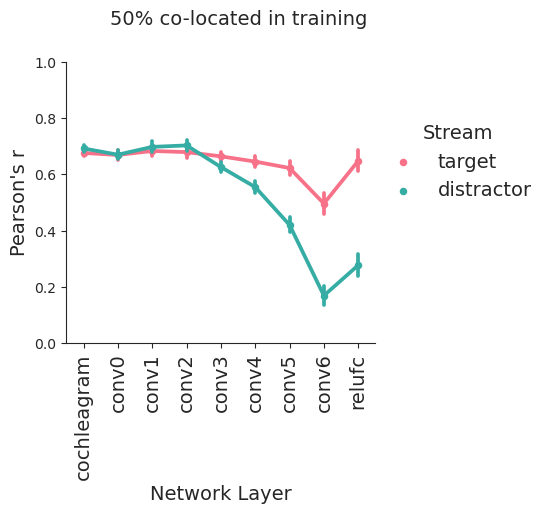

In [74]:
to_plot = results[results['Pearson\'s r'].notna()]
sns.set_style('ticks')

p = sns.catplot(kind='point',data=to_plot, x='layer', y="Pearson's r", order=order,
              hue = 'Stream', palette='husl', 
              height=4, aspect=1, markers='.',
              errorbar=('se', 2), seed=1)
fontsize=14

# plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# g.set_axis_labels("", "Prop. Contour Correct")

p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
# set y limit to 0,1
p.set(ylim=(0,1))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1.1, .6),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("50% co-located in training", size=fontsize)
